In [8]:
from sklearn.datasets import make_classification   #  import synthetic dataset generator
import numpy as np                                  #  import numpy for array/math ops

X, y = make_classification(
    n_samples=100,          #  generate 100 data points total
    n_features=2,           #  use 2 features so the data is plottable in 2D
    n_informative=1,        #  only 1 feature actually carries class signal
    n_redundant=0,          # no redundant (linearly-derived) features
    n_classes=2,            #  binary classification problem
    n_clusters_per_class=1, #  one cluster per class → simple, separable shape
    random_state=41,        #  fix seed for reproducible dataset
    hypercube=False,        #  place cluster centers off the hypercube corners for a more natural spread
    class_sep=10            # push classes far apart → guarantees linear separability, which plain perceptron requires to converge
)

In [9]:
import matplotlib.pyplot as plt   #  import plotting library for visualization

In [10]:
def perceptron(X, y):

    X = np.insert(X, 0, 1, axis=1)
    #  prepend a column of 1s to X at index 0.
    # this is the classic "bias trick" — instead of tracking bias b separately
    # from weights w, we fold it into the weight vector by giving every sample
    # an extra constant feature = 1. Then w0*1 + w1*x1 + w2*x2 = w0 + w1*x1 + w2*x2
    # behaves exactly like (bias + weighted sum), letting one dot product handle both.

    weights = np.ones(X.shape[1])
    #  initialize all weights (including the bias at index 0) to 1.
    # shape matches X's new column count (3: bias + 2 features).

    lr = 0.1
    #  learning rate — controls how big a step each misclassified
    # point pushes the weight vector. Small value → gradual, stable updates.

    for i in range(1000):
        # run 1000 update iterations (stochastic — not full epochs over
        # the dataset, just 1000 random single-sample updates).

        j = np.random.randint(0, 100)
        #  pick one random sample index out of the 100 data points.
        # this is what makes it "stochastic" perceptron learning rather than
        # a full batch pass — one point at a time, in random order.

        y_hat = step(np.dot(X[j], weights))
        #  compute the model's current prediction for that one sample.
        # np.dot(X[j], weights) = w0*1 + w1*x1 + w2*x2 (the weighted sum / "z").
        # step() then thresholds it to 0 or 1 (see cell 4).

        weights = weights + lr * (y[j] - y_hat) * X[j]
        # : THE perceptron trick / update rule.
        # (y[j] - y_hat) is the error:
        #   - if prediction is correct → error = 0 → weights unchanged.
        #   - if true label=1 but predicted 0 → error=+1 → weights move
        #     TOWARD X[j], increasing the weighted sum for similar points
        #     next time (making the boundary more likely to classify it as 1).
        #   - if true label=0 but predicted 1 → error=-1 → weights move
        #     AWAY from X[j], decreasing the weighted sum for similar points.
        # lr scales how large this correction is per mistake.
        # Because X[j] includes the bias column (value 1), weights[0] (the
        # bias) gets updated too, shifting the boundary's offset, not just its angle.

    return weights[0], weights[1:]
    # : split the final weight vector back apart —
    # weights[0] is the learned bias, weights[1:] are the 2 feature coefficients.
    # Returned separately since downstream code (cell 7) treats them differently
    # when converting to a line equation.

In [11]:
def step(z):                    # commit: define the perceptron's activation function
    return 1 if z>0 else 0      # commit: hard threshold — output class 1 if weighted sum is positive, else class 0

In [12]:
intercept_, coef_ = perceptron(X, y)   # : train the perceptron on the full dataset, capture learned bias and weights

In [13]:
print(coef_)        # : inspect the learned feature weights
print(intercept_)   # : inspect the learned bias term

[1.33193777 0.01753016]
0.9


In [14]:
m = -(coef_[0]/coef_[1])
#: derive line slope from the decision boundary equation.
# boundary is coef_[0]*x1 + coef_[1]*x2 + intercept_ = 0.
# solving for x2: x2 = -(coef_[0]/coef_[1])*x1 - (intercept_/coef_[1])
# so slope m = -(coef_[0]/coef_[1]).

b = -(intercept_/coef_[1])
# : derive line y-intercept from the same equation (the constant term above).

In [15]:
x_input = np.linspace(-3, 3, 100)   #  generate 100 evenly-spaced x-values from -3 to 3 to draw the boundary line over
y_input = m*x_input + b              #  compute corresponding y-values using the derived slope/intercept (standard line equation y = mx + b)

(-3.0, 2.0)

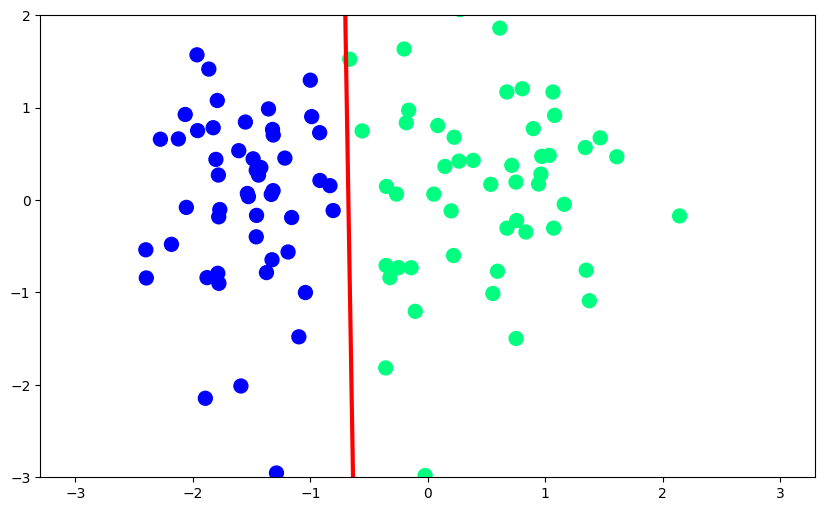

In [16]:
plt.figure(figsize=(10,6))                     # commit: new 10x6 figure for the final plot
plt.plot(x_input, y_input, color='red', linewidth=3)
# draw the learned decision boundary as a thick red line

plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)
# overlay the original data points, colored by true class, on top of the boundary

plt.ylim(-3, 2)
# restrict y-axis view to (-3, 2) to frame the plot nicely around the data/line